In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


DATA LOADING AND ANALYSIS


In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

SEED = 42
np.random.seed(SEED)

PROJECT_PATH = "/content/drive/MyDrive/Demand-Forecasting-AI"
TRAIN_PATH = os.path.join(PROJECT_PATH, "train.csv")
STORE_PATH = os.path.join(PROJECT_PATH, "store.csv")

assert os.path.exists(PROJECT_PATH), f"Project directory not found: {PROJECT_PATH}"
print("Project directory found:", PROJECT_PATH)

Project directory found: /content/drive/MyDrive/Demand-Forecasting-AI


In [3]:
train_raw = pd.read_csv(TRAIN_PATH, low_memory=False, parse_dates=["Date"])
store_raw = pd.read_csv(STORE_PATH, low_memory=False)

print("train_raw:", train_raw.shape)
print("store_raw:", store_raw.shape)

df = train_raw.merge(store_raw, on="Store", how="left", validate="many_to_one")
assert len(df) == len(train_raw), "Row count changed after merge -- investigate join keys"
print("merged:", df.shape)

train_raw: (1017209, 9)
store_raw: (1115, 10)
merged: (1017209, 18)


In [ ]:

report = {}

report["invalid_dates"] = df["Date"].isna().sum()

full_calendar = pd.date_range(df["Date"].min(), df["Date"].max(), freq="D")
report["missing_calendar_days"] = len(full_calendar.difference(df["Date"].unique()))

report["duplicate_store_date_rows"] = df.duplicated(subset=["Store", "Date"]).sum()
report["duplicate_store_ids_in_store_csv"] = store_raw["Store"].duplicated().sum()
report["stores_missing_master_data"] = len(set(train_raw["Store"]) - set(store_raw["Store"]))

report["negative_sales"] = (df["Sales"] < 0).sum()
report["negative_customers"] = (df["Customers"] < 0).sum()
report["invalid_dayofweek"] = (~df["DayOfWeek"].between(1, 7)).sum()
report["invalid_open_flag"] = (~df["Open"].isin([0, 1])).sum()
report["invalid_promo_flag"] = (~df["Promo"].isin([0, 1])).sum()

audit_df = pd.Series(report, name="Count").to_frame()
display(audit_df)

if audit_df["Count"].sum() == 0:
    print("\n All structural checks passed -- data is well-formed.")
else:
    print("\nIssues found above -- see investigation below.")

,Count
invalid_dates,0
missing_calendar_days,0
duplicate_store_date_rows,0
duplicate_store_ids_in_store_csv,0
stores_missing_master_data,0
negative_sales,0
negative_customers,0
invalid_dayofweek,0
invalid_open_flag,0
invalid_promo_flag,0



✅ All structural checks passed -- data is well-formed.


In [ ]:

suspicious = df[(df["Sales"] == 0) & (df["Open"] == 1)].copy()

print(f"Rows with Sales=0 while Open=1: {len(suspicious)} "
      f"({len(suspicious) / len(df) * 100:.3f}% of all rows)")
print("\nOf these, rows with Customers > 0 (genuinely inconsistent):",
      (suspicious["Customers"] > 0).sum())
print("Rows with Customers == 0 (plausible -- store open, no footfall):",
      (suspicious["Customers"] == 0).sum())

print('''
DECISION
--------
Rows are kept, not deleted. Sales=0 with Customers=0 while Open=1 is internally consistent
(a store can be open with zero footfall on a slow day) and dropping them would bias the
target distribution toward higher sales. Rows will instead be handled naturally by the
lag/rolling features and by the "Open" flag, which the model will learn to condition on.
The much larger and unambiguous case -- Open=0 rows -- are excluded before modeling,
since a closed store is not a demand-forecasting instance at all.
''')

Rows with Sales=0 while Open=1: 54 (0.005% of all rows)

Of these, rows with Customers > 0 (genuinely inconsistent): 2
Rows with Customers == 0 (plausible -- store open, no footfall): 52

DECISION
--------
Rows are kept, not deleted. Sales=0 with Customers=0 while Open=1 is internally consistent
(a store can be open with zero footfall on a slow day) and dropping them would bias the
target distribution toward higher sales. Rows will instead be handled naturally by the
lag/rolling features and by the "Open" flag, which the model will learn to condition on.
The much larger and unambiguous case -- Open=0 rows -- are excluded before modeling,
since a closed store is not a demand-forecasting instance at all.



DATA CLEANING

In [ ]:

before = len(df)
df = df[df["Open"] == 1].reset_index(drop=True)
print(f"Dropped {before - len(df)} closed-store rows ({(before-len(df))/before*100:.1f}%)")
print("Remaining shape:", df.shape)

df = df.drop_duplicates().reset_index(drop=True)
print("After exact-duplicate removal:", df.shape)

Dropped 172817 closed-store rows (17.0%)
Remaining shape: (844392, 18)
After exact-duplicate removal: (844392, 18)


In [ ]:

print("Missing values before treatment:")
display(df.isna().sum()[df.isna().sum() > 0])
if "CompetitionDistance" in df.columns:
    df["CompetitionDistance"] = df["CompetitionDistance"].fillna(df["CompetitionDistance"].max())

for col in ["CompetitionOpenSinceMonth", "CompetitionOpenSinceYear"]:
    df[col] = df[col].fillna(0)

for col in ["Promo2SinceWeek", "Promo2SinceYear"]:
    df[col] = df[col].fillna(0)

df["PromoInterval"] = df["PromoInterval"].fillna("None")
print("\nMissing values after treatment:", df.isna().sum().sum())

Missing values before treatment:


,0
CompetitionDistance,2186
CompetitionOpenSinceMonth,268619
CompetitionOpenSinceYear,268619
Promo2SinceWeek,423307
Promo2SinceYear,423307
PromoInterval,423307



Missing values after treatment: 0


EDA

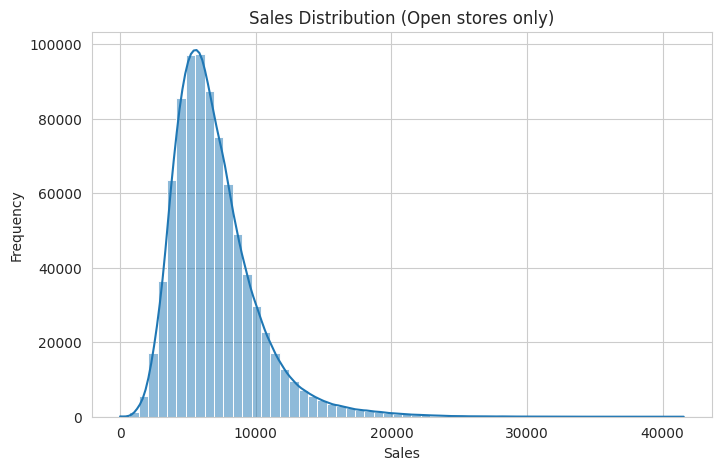

Skewness: 1.59 -- right-skewed, as expected for retail sales. This motivates evaluating log-scale error alongside raw RMSE later.


In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Sales"], bins=60, kde=True)
plt.title("Sales Distribution (Open stores only)")
plt.xlabel("Sales"); plt.ylabel("Frequency")
plt.show()

print(f"Skewness: {df['Sales'].skew():.2f} -- right-skewed, as expected for retail sales. "
      "This motivates evaluating log-scale error alongside raw RMSE later.")

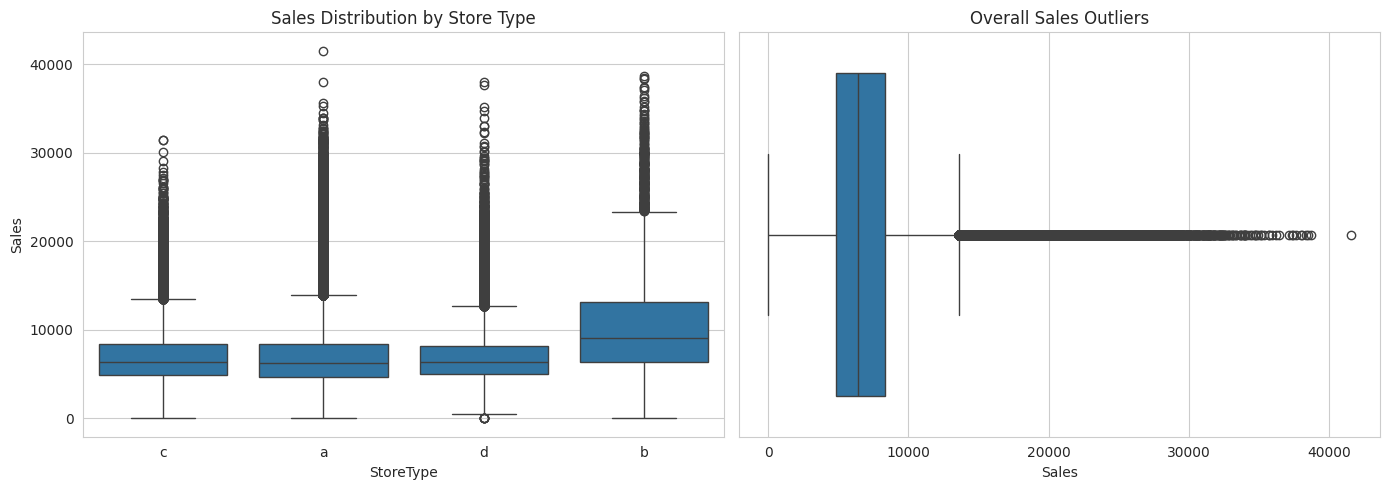

Takeaway: Store Type B has both higher median sales and far heavier upper-tail outliers -- likely larger-format stores. This justifies keeping StoreType as a feature rather than assuming a single global sales distribution.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x=df["StoreType"], y=df["Sales"], ax=axes[0])
axes[0].set_title("Sales Distribution by Store Type")
sns.boxplot(x=df["Sales"], ax=axes[1])
axes[1].set_title("Overall Sales Outliers")
plt.tight_layout(); plt.show()

print("Takeaway: Store Type B has both higher median sales and far heavier upper-tail "
      "outliers -- likely larger-format stores. This justifies keeping StoreType as a feature "
      "rather than assuming a single global sales distribution.")

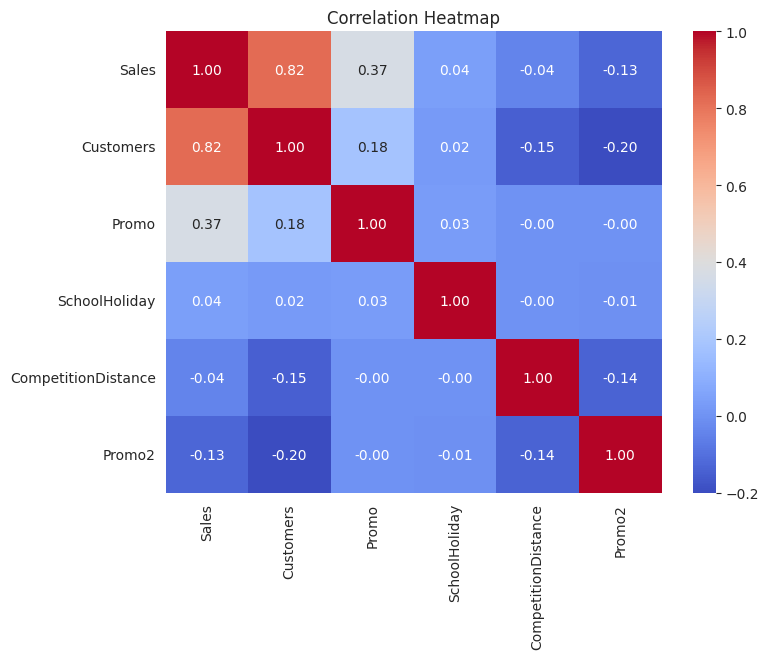

In [10]:
numeric_cols = ["Sales", "Customers", "Promo", "SchoolHoliday",
                 "CompetitionDistance", "Promo2"]
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

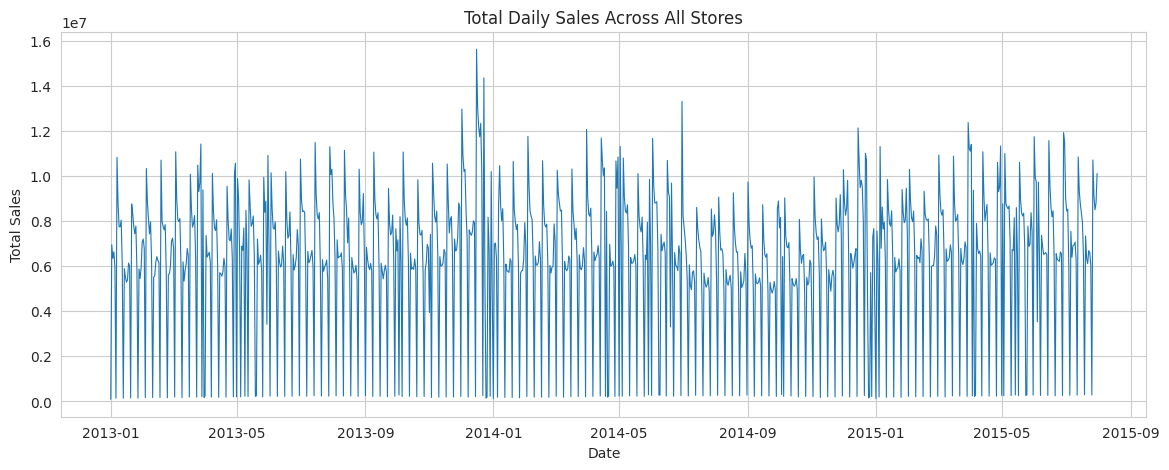

Takeaway: strong weekly seasonality and clear dips around Christmas closures -- confirms lag/rolling features must be store-and-calendar aware, not just a raw shift.


In [11]:
daily = df.groupby("Date").agg(Sales=("Sales", "sum"),
                                 SchoolHoliday=("SchoolHoliday", "mean")).reset_index()

plt.figure(figsize=(14, 5))
plt.plot(daily["Date"], daily["Sales"], linewidth=0.8)
plt.title("Total Daily Sales Across All Stores")
plt.xlabel("Date"); plt.ylabel("Total Sales")
plt.show()

print("Takeaway: strong weekly seasonality and clear dips around Christmas closures -- "
      "confirms lag/rolling features must be store-and-calendar aware, not just a raw shift.")

In [12]:
promo_stats = df.groupby("Promo")["Sales"].agg(["mean", "median", "count"])
display(promo_stats)

t_stat, p_val = stats.ttest_ind(
    df.loc[df["Promo"] == 1, "Sales"],
    df.loc[df["Promo"] == 0, "Sales"],
    equal_var=False
)
print(f"Welch t-test: t={t_stat:.2f}, p={p_val:.2e}")
print("Takeaway: the promo uplift is statistically significant (not just a large-sample "
      "artifact), confirming Promo is a genuinely causal-looking feature, not noise.")

,mean,median,count
Promo,,,
0,5929.407603,5459.0,467496
1,8228.281239,7649.0,376896


Welch t-test: t=356.64, p=0.00e+00
Takeaway: the promo uplift is statistically significant (not just a large-sample artifact), confirming Promo is a genuinely causal-looking feature, not noise.


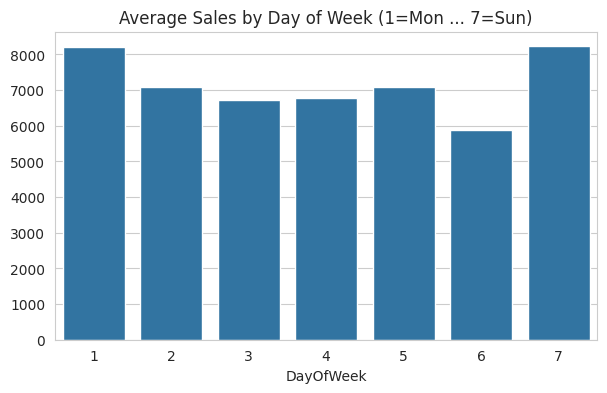

Takeaway: Sunday (7) sales are near zero for most stores (closed in many German states) -- day-of-week must be encoded, and ideally cyclically, not just as an integer.


In [13]:
dow_sales = df.groupby("DayOfWeek")["Sales"].mean()
plt.figure(figsize=(7, 4))
sns.barplot(x=dow_sales.index, y=dow_sales.values)
plt.title("Average Sales by Day of Week (1=Mon ... 7=Sun)")
plt.show()
print("Takeaway: Sunday (7) sales are near zero for most stores (closed in many German "
      "states) -- day-of-week must be encoded, and ideally cyclically, not just as an integer.")

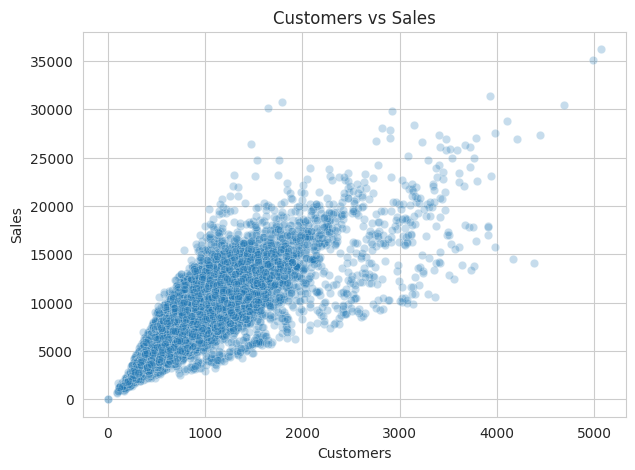

Correlation: 0.82 -- very strong, but Customers is NOT known at prediction time, so it must be excluded from the feature set (confirmed again explicitly in Section 4 to prevent silent leakage).


In [14]:
sample = df.sample(min(30000, len(df)), random_state=SEED)
plt.figure(figsize=(7, 5))
sns.scatterplot(data=sample, x="Customers", y="Sales", alpha=0.25)
plt.title("Customers vs Sales")
plt.show()
print(f"Correlation: {df['Customers'].corr(df['Sales']):.2f} -- very strong, but Customers "
      "is NOT known at prediction time, so it must be excluded from the feature set "
      "(confirmed again explicitly in Section 4 to prevent silent leakage).")

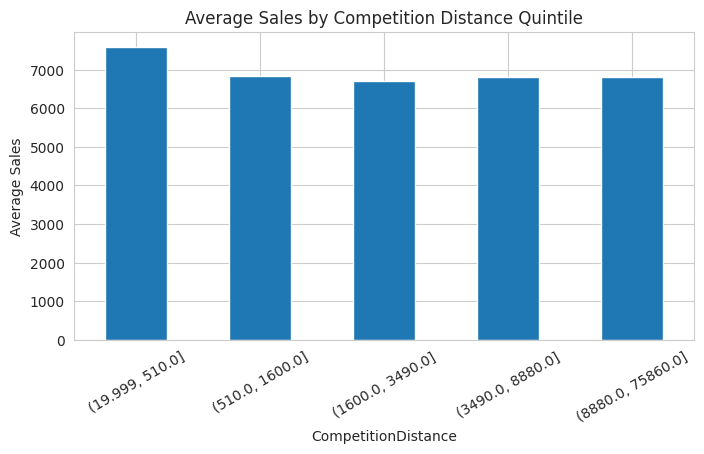

Takeaway: no strong monotonic effect -- competition proximity alone is a weak signal; it will be kept but is not expected to dominate feature importance.


In [15]:
comp_dist_bins = pd.qcut(df["CompetitionDistance"], 5, duplicates="drop")
comp_effect = df.groupby(comp_dist_bins)["Sales"].mean()
plt.figure(figsize=(8, 4))
comp_effect.plot(kind="bar")
plt.title("Average Sales by Competition Distance Quintile")
plt.ylabel("Average Sales"); plt.xticks(rotation=30)
plt.show()
print("Takeaway: no strong monotonic effect -- competition proximity alone is a weak "
      "signal; it will be kept but is not expected to dominate feature importance.")

FEATURE ENGINEERING

In [ ]:
df = df.sort_values(["Store", "Date"]).reset_index(drop=True)
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
df["IsWeekend"] = (df["DayOfWeek"] >= 6).astype(int)
df["IsMonthStart"] = df["Date"].dt.is_month_start.astype(int)
df["IsMonthEnd"] = df["Date"].dt.is_month_end.astype(int)

df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)
df["DayOfWeek_sin"] = np.sin(2 * np.pi * df["DayOfWeek"] / 7)
df["DayOfWeek_cos"] = np.cos(2 * np.pi * df["DayOfWeek"] / 7)

print("Calendar features added:", df.shape)

Calendar features added: (844392, 29)


In [ ]:

comp_date = pd.to_datetime(dict(
    year=df["CompetitionOpenSinceYear"].replace(0, np.nan),
    month=df["CompetitionOpenSinceMonth"].replace(0, np.nan),
    day=1
), errors="coerce")
df["CompetitionOpenMonths"] = ((df["Date"] - comp_date).dt.days / 30).clip(lower=0).fillna(0)

promo2_date = pd.to_datetime(
    df["Promo2SinceYear"].astype(int).astype(str) + "-" +
    df["Promo2SinceWeek"].astype(int).astype(str) + "-1",
    format="%Y-%W-%w", errors="coerce"
)
df["Promo2OpenWeeks"] = ((df["Date"] - promo2_date).dt.days / 7).clip(lower=0).fillna(0)
month_map = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
             7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
df["MonthStr"] = df["Month"].map(month_map)
promo_interval_str = df["PromoInterval"].astype(str)
in_interval = [m in s.split(",") for m, s in zip(df["MonthStr"], promo_interval_str)]
df["IsPromo2Month"] = ((df["Promo2"] == 1) & pd.Series(in_interval, index=df.index)).astype(int)
df = df.drop(columns=["MonthStr"])
print("Competition/Promo2 tenure features added:", df.shape)

Competition/Promo2 tenure features added: (844392, 32)


In [ ]:

def add_lag_rolling_features(data, sales_col="Sales"):
    data = data.sort_values(["Store", "Date"]).copy()
    g = data.groupby("Store")[sales_col]

    for lag in [1, 7, 14, 30]:
        data[f"Sales_lag_{lag}"] = g.shift(lag)

    for window in [7, 14, 30]:
        shifted = g.shift(1)
        data[f"Sales_roll_mean_{window}"] = shifted.groupby(data["Store"]).transform(
            lambda x: x.rolling(window, min_periods=3).mean())
        data[f"Sales_roll_std_{window}"] = shifted.groupby(data["Store"]).transform(
            lambda x: x.rolling(window, min_periods=3).std())

    data["Sales_ewm_7"] = g.transform(lambda x: x.shift(1).ewm(span=7, min_periods=3).mean())

    return data

df = add_lag_rolling_features(df)
lag_roll_cols = [c for c in df.columns if c.startswith("Sales_lag") or c.startswith("Sales_roll") or c.startswith("Sales_ewm")]
print("Lag/rolling features added:", lag_roll_cols)
print("NaN rate before fill (expected -- early rows per store):")
display(df[lag_roll_cols].isna().mean())

Lag/rolling features added: ['Sales_lag_1', 'Sales_lag_7', 'Sales_lag_14', 'Sales_lag_30', 'Sales_roll_mean_7', 'Sales_roll_std_7', 'Sales_roll_mean_14', 'Sales_roll_std_14', 'Sales_roll_mean_30', 'Sales_roll_std_30', 'Sales_ewm_7']
NaN rate before fill (expected -- early rows per store):


,0
Sales_lag_1,0.001320
Sales_lag_7,0.009243
Sales_lag_14,0.018487
Sales_lag_30,0.039614
Sales_roll_mean_7,0.003961
Sales_roll_std_7,0.003961
Sales_roll_mean_14,0.003961
Sales_roll_std_14,0.003961
Sales_roll_mean_30,0.003961
Sales_roll_std_30,0.003961


In [ ]:

for col in lag_roll_cols:
    df[col] = df[col].fillna(0)

print("Feature engineering complete:", df.shape)

Feature engineering complete: (844392, 43)


In [ ]:
df = df.sort_values(["Date", "Store"]).reset_index(drop=True)

TRAIN_END = "2015-05-01"
VALID_END = "2015-06-15"
train_data = df[df["Date"] < TRAIN_END].copy()
valid_data = df[(df["Date"] >= TRAIN_END) & (df["Date"] < VALID_END)].copy()
test_data  = df[df["Date"] >= VALID_END].copy()

for name, d in [("Train", train_data), ("Valid", valid_data), ("Test", test_data)]:
    print(f"{name}: {d.shape}, {d['Date'].min().date()} -> {d['Date'].max().date()}")

Train: (759901, 43), 2013-01-01 -> 2015-04-30
Valid: (38639, 43), 2015-05-01 -> 2015-06-14
Test: (45852, 43), 2015-06-15 -> 2015-07-31


In [ ]:

cat_cols = ["StoreType", "Assortment", "StateHoliday"]
def encode_categoricals(data, reference_columns=None):
    d = pd.get_dummies(data, columns=cat_cols, drop_first=True)
    if reference_columns is not None:
        d = d.reindex(columns=reference_columns, fill_value=0)
    return d

train_enc = encode_categoricals(train_data)
reference_cols = train_enc.columns
valid_enc = encode_categoricals(valid_data, reference_cols)
test_enc  = encode_categoricals(test_data, reference_cols)

print(train_enc.shape, valid_enc.shape, test_enc.shape)

(759901, 48) (38639, 48) (45852, 48)


TRAIN TEST SPLIT

In [ ]:

LEAKAGE_COLS = ["Sales", "Customers", "Date", "Open", "PromoInterval"]  
FEATURE_COLS = [c for c in train_enc.columns if c not in LEAKAGE_COLS]
X_train, y_train = train_enc[FEATURE_COLS], train_enc["Sales"]
X_valid, y_valid = valid_enc[FEATURE_COLS], valid_enc["Sales"]
X_test,  y_test  = test_enc[FEATURE_COLS],  test_enc["Sales"]
print("Feature count:", len(FEATURE_COLS))
print("X_train:", X_train.shape, "X_valid:", X_valid.shape, "X_test:", X_test.shape)
print("\nFeatures used by EVERY model in this notebook (fair comparison):")
print(FEATURE_COLS)

Feature count: 43
X_train: (759901, 43) X_valid: (38639, 43) X_test: (45852, 43)

Features used by EVERY model in this notebook (fair comparison):
['Store', 'DayOfWeek', 'Promo', 'SchoolHoliday', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'Year', 'Month', 'Day', 'WeekOfYear', 'IsWeekend', 'IsMonthStart', 'IsMonthEnd', 'Month_sin', 'Month_cos', 'DayOfWeek_sin', 'DayOfWeek_cos', 'CompetitionOpenMonths', 'Promo2OpenWeeks', 'IsPromo2Month', 'Sales_lag_1', 'Sales_lag_7', 'Sales_lag_14', 'Sales_lag_30', 'Sales_roll_mean_7', 'Sales_roll_std_7', 'Sales_roll_mean_14', 'Sales_roll_std_14', 'Sales_roll_mean_30', 'Sales_roll_std_30', 'Sales_ewm_7', 'StoreType_b', 'StoreType_c', 'StoreType_d', 'Assortment_b', 'Assortment_c', 'StateHoliday_a', 'StateHoliday_b', 'StateHoliday_c']


In [ ]:
def rmspe(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))

def evaluate(y_true, y_pred, name):
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    result = {
        "Model": name,
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "RMSPE": rmspe(y_true, y_pred),
    }
    return result

results = [] 

In [ ]:

results.append(evaluate(y_test, test_enc["Sales_lag_1"], "Baseline: Last Value (lag-1)"))
results.append(evaluate(y_test, test_enc["Sales_lag_7"], "Baseline: Same Day Last Week (lag-7)"))
results.append(evaluate(y_test, test_enc["Sales_roll_mean_30"], "Baseline: 30-Day Rolling Mean"))
pd.DataFrame(results)

,Model,RMSE,MAE,R2,RMSPE
0,Baseline: Last Value (lag-1),2108.798173,1368.419764,0.533996,0.305181
1,Baseline: Same Day Last Week (lag-7),3047.383677,2404.135632,0.026863,0.470540
2,Baseline: 30-Day Rolling Mean,1901.938842,1427.553593,0.620936,0.311817


COMPARE DIFFERENT ML MODELS

In [ ]:
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

param_dist = {
    "max_depth": [4, 5, 6, 7],
    "min_child_weight": [5, 10, 15],
    "learning_rate": [0.01, 0.03, 0.05],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 5, 10],
}

tscv = TimeSeriesSplit(n_splits=2)

xgb_base = xgb.XGBRegressor(
    n_estimators=300, objective="reg:squarederror", tree_method="hist",
    random_state=SEED, n_jobs=-1
)

xgb_search = RandomizedSearchCV(
    xgb_base, param_distributions=param_dist, n_iter=6,
    scoring="neg_root_mean_squared_error", cv=tscv,
    random_state=SEED, n_jobs=-1, verbose=1
)
xgb_search.fit(X_train, y_train)
print("Best CV RMSE:", -xgb_search.best_score_)
print("Best params:", xgb_search.best_params_)

Fitting 2 folds for each of 6 candidates, totalling 12 fits
Best CV RMSE: 1161.0286254882812
Best params: {'subsample': 0.9, 'reg_lambda': 5, 'reg_alpha': 1, 'min_child_weight': 10, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


In [26]:
xgb_model = xgb.XGBRegressor(
    **xgb_search.best_params_,
    n_estimators=3000, objective="reg:squarederror", eval_metric="rmse",
    tree_method="hist", random_state=SEED, n_jobs=-1, early_stopping_rounds=50
)
xgb_model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=200)
print("Best iteration:", xgb_model.best_iteration)

xgb_test_pred = xgb_model.predict(X_test)
results.append(evaluate(y_test, xgb_test_pred, "XGBoost (tuned)"))
pd.DataFrame(results).sort_values("RMSPE")

[0]	validation_0-rmse:2934.91587
[200]	validation_0-rmse:1018.64073
[400]	validation_0-rmse:971.88000
[600]	validation_0-rmse:954.01078
[676]	validation_0-rmse:954.68388
Best iteration: 626


,Model,RMSE,MAE,R2,RMSPE
3,XGBoost (tuned),862.014719,612.769897,0.922134,0.126285
0,Baseline: Last Value (lag-1),2108.798173,1368.419764,0.533996,0.305181
2,Baseline: 30-Day Rolling Mean,1901.938842,1427.553593,0.620936,0.311817
1,Baseline: Same Day Last Week (lag-7),3047.383677,2404.135632,0.026863,0.470540


In [27]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=3000, learning_rate=0.03, max_depth=7,
    num_leaves=63, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=5, random_state=SEED, n_jobs=-1
)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(200)]
)

lgb_test_pred = lgb_model.predict(X_test)
results.append(evaluate(y_test, lgb_test_pred, "LightGBM"))
pd.DataFrame(results).sort_values("RMSPE")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.153582 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4070
[LightGBM] [Info] Number of data points in the train set: 759901, number of used features: 43
[LightGBM] [Info] Start training from score 6927.679707
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[200]	valid_0's l2: 1.11828e+06
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[400]	valid_0's l2: 1.00534e+06
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [War

,Model,RMSE,MAE,R2,RMSPE
4,LightGBM,846.513887,604.886413,0.924909,0.124253
3,XGBoost (tuned),862.014719,612.769897,0.922134,0.126285
0,Baseline: Last Value (lag-1),2108.798173,1368.419764,0.533996,0.305181
2,Baseline: 30-Day Rolling Mean,1901.938842,1427.553593,0.620936,0.311817
1,Baseline: Same Day Last Week (lag-7),3047.383677,2404.135632,0.026863,0.470540


In [ ]:
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
import gc
WINDOW = 30
SEQ_FEATURES = FEATURE_COLS  
n_features = len(SEQ_FEATURES)
scalers = {col: MinMaxScaler().fit(train_enc[[col]]) for col in SEQ_FEATURES}
target_scaler = MinMaxScaler().fit(train_enc[["Sales"]])
def _scale_matrix(data):
    out = np.empty((len(data), n_features), dtype=np.float32)
    for j, col in enumerate(SEQ_FEATURES):
        out[:, j] = scalers[col].transform(data[[col]]).flatten()
    return out

def count_sequences(data, window=WINDOW):
    counts = data.groupby("Store").size()
    return int((counts - window).clip(lower=0).sum())

def make_dataset(data, window=WINDOW, batch_size=512, shuffle=False, shuffle_buffer=20000):
    data = data.sort_values(["Store", "Date"])
    scaled_X = _scale_matrix(data)
    scaled_y = target_scaler.transform(data[["Sales"]]).flatten().astype(np.float32)
    store_ids = data["Store"].values
    unique_stores = np.unique(store_ids)

    def gen():
        for store in unique_stores:
            mask = store_ids == store
            store_X = scaled_X[mask]
            store_y = scaled_y[mask]
            for i in range(window, len(store_X)):
                yield store_X[i - window:i], store_y[i]

    ds = tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec(shape=(window, n_features), dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.float32),
        ),
    )
    if shuffle:
        ds = ds.shuffle(shuffle_buffer, seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

def sequence_targets(data, window=WINDOW):
    data = data.sort_values(["Store", "Date"])
    scaled_y = target_scaler.transform(data[["Sales"]]).flatten().astype(np.float32)
    store_ids = data["Store"].values
    y_out = []
    for store in np.unique(store_ids):
        sy = scaled_y[store_ids == store]
        if len(sy) > window:
            y_out.append(sy[window:])
    return np.concatenate(y_out).astype(np.float32)
train_hist = train_data.groupby("Store").tail(WINDOW)
valid_with_hist = pd.concat([train_hist, valid_data]).sort_values(["Store", "Date"])
valid_hist = valid_with_hist.groupby("Store").tail(WINDOW)
test_with_hist = pd.concat([valid_hist, test_data]).sort_values(["Store", "Date"])

valid_with_hist_enc = encode_categoricals(valid_with_hist, reference_cols)
test_with_hist_enc = encode_categoricals(test_with_hist, reference_cols)

BATCH_SIZE = 1024
train_ds = make_dataset(train_enc, batch_size=BATCH_SIZE, shuffle=True)
valid_ds = make_dataset(valid_with_hist_enc, batch_size=BATCH_SIZE)
test_ds  = make_dataset(test_with_hist_enc, batch_size=BATCH_SIZE)

y_dl_train_count = count_sequences(train_enc)
y_dl_valid = sequence_targets(valid_with_hist_enc)
y_dl_test  = sequence_targets(test_with_hist_enc)

print("Train seq:", y_dl_train_count, "| Valid seq:", len(y_dl_valid),
      "| Test seq:", len(y_dl_test), "| n_features:", n_features)
gc.collect()


Train seq: 726451 | Valid seq: 38639 | Test seq: 45852 | n_features: 43


7755

In [ ]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (LSTM, GRU, Dense, Dropout, Input,
                                      LayerNormalization, MultiHeadAttention,
                                      GlobalAveragePooling1D)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import gc

def inverse_target(y_scaled):
    return target_scaler.inverse_transform(y_scaled.reshape(-1, 1)).flatten()

callbacks = lambda: [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
]


In [ ]:

lstm_model = Sequential([
    LSTM(64, input_shape=(WINDOW, n_features), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])
lstm_model.compile(optimizer=Adam(1e-3), loss="mse", metrics=["mae"])

lstm_history = lstm_model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=5, callbacks=callbacks(), verbose=1
)

lstm_test_pred = inverse_target(lstm_model.predict(test_ds).flatten())
lstm_test_actual = inverse_target(y_dl_test)
results.append(evaluate(lstm_test_actual, lstm_test_pred, "LSTM (multivariate)"))

gc.collect()


Epoch 1/5
710/710 ━━━━━━━━━━━━━━━━━━━━ 236s 321ms/step - loss: 0.0027 - mae: 0.0370 - val_loss: 0.0015 - val_mae: 0.0298 - learning_rate: 0.0010
Epoch 2/5
710/710 ━━━━━━━━━━━━━━━━━━━━ 225s 309ms/step - loss: 0.0014 - mae: 0.0272 - val_loss: 0.0012 - val_mae: 0.0251 - learning_rate: 0.0010
Epoch 3/5
710/710 ━━━━━━━━━━━━━━━━━━━━ 225s 310ms/step - loss: 0.0012 - mae: 0.0246 - val_loss: 0.0012 - val_mae: 0.0251 - learning_rate: 0.0010
Epoch 4/5
710/710 ━━━━━━━━━━━━━━━━━━━━ 223s 307ms/step - loss: 0.0010 - mae: 0.0229 - val_loss: 0.0011 - val_mae: 0.0239 - learning_rate: 0.0010
Epoch 5/5
710/710 ━━━━━━━━━━━━━━━━━━━━ 224s 308ms/step - loss: 9.2230e-04 - mae: 0.0214 - val_loss: 0.0010 - val_mae: 0.0228 - learning_rate: 0.0010
45/45 ━━━━━━━━━━━━━━━━━━━━ 13s 291ms/step


64

In [ ]:

gru_model = Sequential([
    GRU(64, input_shape=(WINDOW, n_features)),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])
gru_model.compile(optimizer=Adam(1e-3), loss="mse", metrics=["mae"])

gru_history = gru_model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=5, callbacks=callbacks(), verbose=1
)

gru_test_pred = inverse_target(gru_model.predict(test_ds).flatten())
gru_test_actual = inverse_target(y_dl_test)
results.append(evaluate(gru_test_actual, gru_test_pred, "GRU (multivariate)"))

gc.collect()


Epoch 1/5
710/710 ━━━━━━━━━━━━━━━━━━━━ 225s 308ms/step - loss: 0.0038 - mae: 0.0431 - val_loss: 0.0018 - val_mae: 0.0335 - learning_rate: 0.0010
Epoch 2/5
710/710 ━━━━━━━━━━━━━━━━━━━━ 224s 307ms/step - loss: 0.0015 - mae: 0.0278 - val_loss: 0.0013 - val_mae: 0.0279 - learning_rate: 0.0010
Epoch 3/5
710/710 ━━━━━━━━━━━━━━━━━━━━ 224s 308ms/step - loss: 0.0012 - mae: 0.0251 - val_loss: 9.9348e-04 - val_mae: 0.0228 - learning_rate: 0.0010
Epoch 4/5
710/710 ━━━━━━━━━━━━━━━━━━━━ 225s 309ms/step - loss: 0.0011 - mae: 0.0232 - val_loss: 0.0012 - val_mae: 0.0266 - learning_rate: 0.0010
Epoch 5/5
710/710 ━━━━━━━━━━━━━━━━━━━━ 226s 310ms/step - loss: 9.7763e-04 - mae: 0.0220 - val_loss: 0.0010 - val_mae: 0.0236 - learning_rate: 0.0010
45/45 ━━━━━━━━━━━━━━━━━━━━ 13s 285ms/step


68

In [ ]:

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.2):
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    x = Dropout(dropout)(x)
    x = LayerNormalization(epsilon=1e-6)(inputs + x)
    x_ff = Dense(ff_dim, activation="relu")(x)
    x_ff = Dropout(dropout)(x_ff)
    x_ff = Dense(inputs.shape[-1])(x_ff)
    return LayerNormalization(epsilon=1e-6)(x + x_ff)

inputs = Input(shape=(WINDOW, n_features))
x = transformer_encoder(inputs, head_size=32, num_heads=2, ff_dim=64, dropout=0.2)
x = GlobalAveragePooling1D()(x)
x = Dense(32, activation="relu")(x)
x = Dropout(0.2)(x)
outputs = Dense(1)(x)

transformer_model = Model(inputs, outputs)
transformer_model.compile(optimizer=Adam(3e-4, clipnorm=1.0), loss="mse", metrics=["mae"])

transformer_history = transformer_model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=5, callbacks=callbacks(), verbose=1
)

transformer_test_pred = inverse_target(transformer_model.predict(test_ds).flatten())
transformer_test_actual = inverse_target(y_dl_test)
results.append(evaluate(transformer_test_actual, transformer_test_pred, "Transformer (multivariate)"))

gc.collect()


Epoch 1/5
710/710 ━━━━━━━━━━━━━━━━━━━━ 244s 319ms/step - loss: 0.0158 - mae: 0.0726 - val_loss: 0.0057 - val_mae: 0.0618 - learning_rate: 3.0000e-04
Epoch 2/5
710/710 ━━━━━━━━━━━━━━━━━━━━ 224s 308ms/step - loss: 0.0040 - mae: 0.0469 - val_loss: 0.0048 - val_mae: 0.0562 - learning_rate: 3.0000e-04
Epoch 3/5
710/710 ━━━━━━━━━━━━━━━━━━━━ 224s 309ms/step - loss: 0.0033 - mae: 0.0423 - val_loss: 0.0042 - val_mae: 0.0522 - learning_rate: 3.0000e-04
Epoch 4/5
710/710 ━━━━━━━━━━━━━━━━━━━━ 228s 313ms/step - loss: 0.0029 - mae: 0.0399 - val_loss: 0.0036 - val_mae: 0.0478 - learning_rate: 3.0000e-04
Epoch 5/5
710/710 ━━━━━━━━━━━━━━━━━━━━ 226s 310ms/step - loss: 0.0027 - mae: 0.0384 - val_loss: 0.0031 - val_mae: 0.0437 - learning_rate: 3.0000e-04
45/45 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step


1228

,Model,RMSE,MAE,R2,RMSPE
0,LightGBM,846.513887,604.886413,0.924909,0.124253
1,XGBoost (tuned),862.014719,612.769897,0.922134,0.126285
2,LSTM (multivariate),1113.205057,787.784546,0.870142,0.183138
3,GRU (multivariate),1174.889888,843.145752,0.855351,0.205888
4,Baseline: Last Value (lag-1),2108.798173,1368.419764,0.533996,0.305181
5,Baseline: 30-Day Rolling Mean,1901.938842,1427.553593,0.620936,0.311817
6,Baseline: Same Day Last Week (lag-7),3047.383677,2404.135632,0.026863,0.470540
7,Transformer (multivariate),2432.380110,1945.743652,0.380013,0.485834


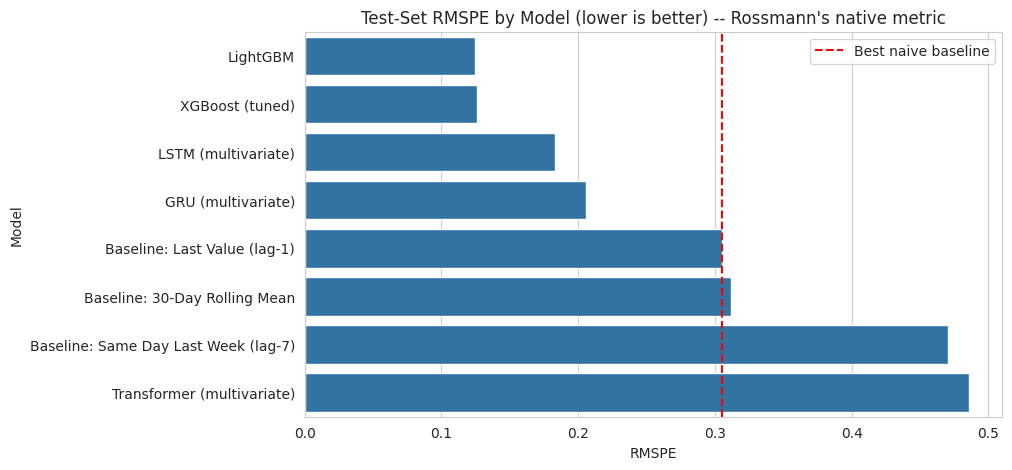

Best model on held-out test set: LightGBM


In [41]:
results_df = pd.DataFrame(results).sort_values("RMSPE").reset_index(drop=True)
display(results_df)

plt.figure(figsize=(9, 5))
sns.barplot(data=results_df, x="RMSPE", y="Model")
plt.title("Test-Set RMSPE by Model (lower is better) -- Rossmann's native metric")
plt.axvline(results_df.loc[results_df["Model"].str.contains("Baseline"), "RMSPE"].min(),
            color="red", linestyle="--", label="Best naive baseline")
plt.legend()
plt.show()

best_model_name = results_df.iloc[0]["Model"]
print(f"Best model on held-out test set: {best_model_name}")

SHAP EXPLAINABILITY

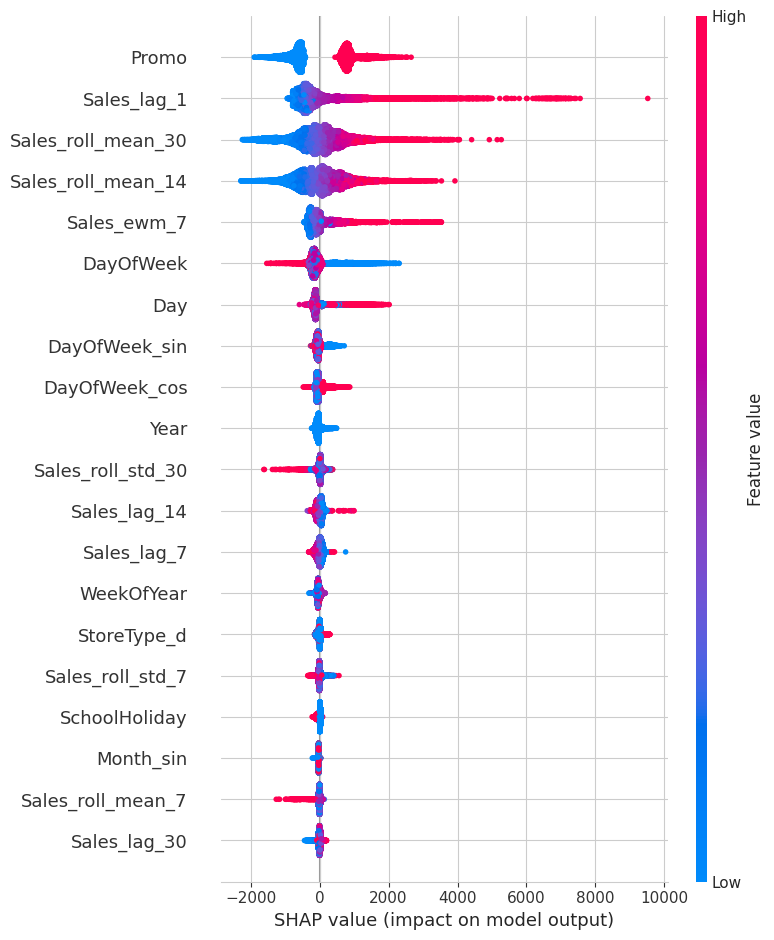

,Feature,Mean_SHAP_Impact
2,Promo,820.783386
24,Sales_lag_1,610.314148
32,Sales_roll_mean_30,566.600952
30,Sales_roll_mean_14,535.571777
34,Sales_ewm_7,298.749237
1,DayOfWeek,275.025940
12,Day,235.400269
19,DayOfWeek_sin,101.768303
20,DayOfWeek_cos,98.034660
10,Year,68.177734


In [ ]:
!pip install shap -q
import shap

tree_model = xgb_model if results_df.iloc[0]["Model"].startswith("XGBoost") or True else lgb_model
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test.sample(min(20000, len(X_test)), random_state=SEED))
sample_X = X_test.sample(min(20000, len(X_test)), random_state=SEED)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, sample_X, show=False)
plt.tight_layout(); plt.show()

shap_importance = pd.DataFrame({
    "Feature": sample_X.columns,
    "Mean_SHAP_Impact": np.abs(shap_values).mean(axis=0)
}).sort_values("Mean_SHAP_Impact", ascending=False)

display(shap_importance.head(15))

MODELS SAVED

In [43]:
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(xgb_model, "models/xgboost_model.pkl")
joblib.dump(lgb_model, "models/lightgbm_model.pkl")
lstm_model.save("models/lstm_model.keras")
gru_model.save("models/gru_model.keras")
transformer_model.save("models/transformer_model.keras")

joblib.dump(FEATURE_COLS, "models/feature_list.pkl")
joblib.dump(scalers, "models/feature_scalers.pkl")
joblib.dump(target_scaler, "models/target_scaler.pkl")
joblib.dump(explainer, "models/shap_explainer.pkl")
results_df.to_csv("models/model_comparison_results.csv", index=False)
shap_importance.to_csv("models/shap_feature_importance.csv", index=False)

print("All artifacts saved to ./models/")
print(os.listdir("models"))

All artifacts saved to ./models/
['shap_feature_importance.csv', 'target_scaler.pkl', 'feature_list.pkl', 'xgboost_model.pkl', 'lstm_model.keras', 'model_comparison_results.csv', 'feature_scalers.pkl', 'gru_model.keras', 'lightgbm_model.pkl', 'shap_explainer.pkl', 'transformer_model.keras']


In [47]:
import shutil

shutil.make_archive("models_backup", "zip", "models")

print("Created models_backup.zip")

Created models_backup.zip


In [48]:
from google.colab import files

files.download("models_backup.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>